# For running covariance measurement
Anik pointed out that the DS factor on inv cov is important.
Because DS factor would degrade the FoM, we thought it is better to increase the nubmer of simulations to get more accurate covariance.

This notebook estimates the number of covariance needed.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint
plt.switch_backend('module://matplotlib_inline.backend_inline')

## Notebook on Feb 18 2025

We need to include Dodelson-Schneider factor.

In [3]:
blind = False

mock_2pt = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=blind)

# LCDM
mock_2pt_map3 = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in


In [4]:
# LCDM explicitly included DS factor in like, and ran mcmc
mock_2pt_map3_ds = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-dsfactor2025/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)

Removed no burn in


In [5]:
# here we instead, predict the effect of DS factor by MC sample reweighting method (can be inaccurate but a rough estimate).
f = (1 + (96-16)*(500-96-2)/(500-96-1)/(500-96-4))**-1
print(f)

mock_2pt_map3_rew = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind, f_icov=f)

0.833678113363674
Removed no burn in


In [6]:
# previous version
fom_gain = utils.FoM_from_samples_names(mock_2pt_map3, ['s8', 'om'])/ utils.FoM_from_samples_names(mock_2pt, ['s8','om'])
print(fom_gain)

# DS factor version
fom_gain = utils.FoM_from_samples_names(mock_2pt_map3_ds, ['s8', 'om'])/ utils.FoM_from_samples_names(mock_2pt, ['s8','om'])
print(fom_gain)

1.953623582968164
1.6753967308838378


improvement is degraded, by DS factor....

Let's see what happens if we increase the number of the sims for cov estiamte.

In [7]:
# current nsim = 516
# let's increase by 280

nsim = 516 + 280
f2 = (1 + (96-16)*(nsim-96-2)/(nsim-96-1)/(nsim-96-4))**-1 # DS factor
f1 = (nsim-96-2)/(nsim-1) # updated Hartlap factor 
f1_now = (500-96-2)/(500-1) # already exising H factor
f  = f2 * f1/f1_now # DS factor * relative H factor
print(f2, f1, f)

mock_2pt_map3_rew_more = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind, f_icov=f)

0.8970395173542992 0.8779874213836478 0.9776296441488692
Removed no burn in


In [8]:
fom_gain = utils.FoM_from_samples_names(mock_2pt_map3_rew_more, ['s8', 'om'])/ utils.FoM_from_samples_names(mock_2pt, ['s8','om'])
print(fom_gain)

1.9270906007193422


Okay, with this number of sims, we can recover the fom_gain to what we had previously.

## Here we identify the number of map3 files 

In [9]:
# measurement results
#/global/cfs/cdirs/des/ssunao/3pcf/measurement/all_4k_weighted_measurements/map3

In [10]:
from glob import glob
import os
from tqdm import tqdm

In [11]:
nsims = 0
dirname = '/global/cfs/cdirs/des/ssunao/3pcf/measurement/all_4k_weighted_measurements/map3'
missings = []

for run in tqdm(range(200)):
    for cut in range(4):
        for real in range(5):
            fname = f"map3_cosmogrid_run{run:04d}_cut{cut:02d}_real{real:02d}_z*_z*_z*.dat"
            files = glob(os.path.join(dirname, fname))
            nfiles= len(files)

            # If nfiles == 20, then all z-bin measurements
            # for this map realization are done, and we count 
            # 1 as the number of sims.
            nsims += 1 if nfiles == 20 else 0

            # If not we add how much files are 
            # missing for this map
            if nfiles < 20:
                missings.append([run, cut, real, nfiles])

missings = np.array(missings)
missings = missings[np.argsort(missings[:,-1]), :]

100%|██████████| 200/200 [01:33<00:00,  2.14it/s]


In [12]:
# number of the sims for which all-z map3 measurements are done
nsims

516

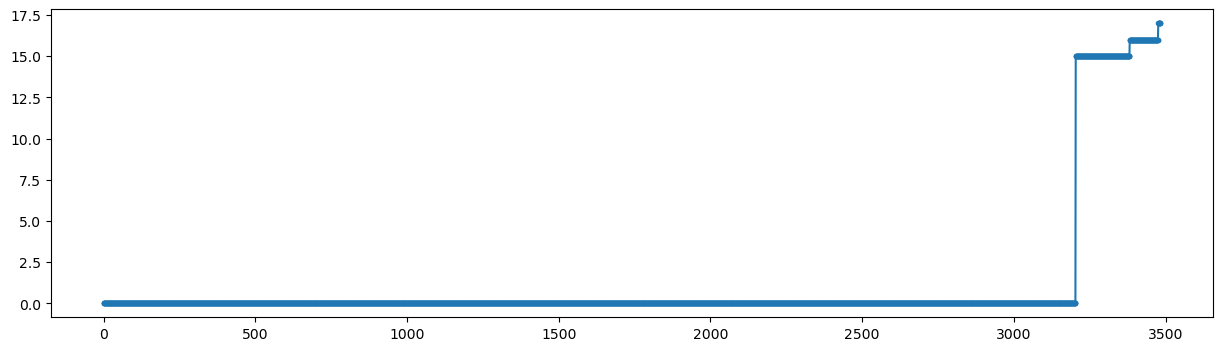

In [13]:
plt.figure(figsize=(15, 4))
plt.plot(missings[:, -1], marker='.')
plt.show()

In [14]:
idx = missings[:, -1] >= 15

In [15]:
# show the number of the finished files
missings[idx,-1]

array([15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16

In [16]:
# number of measurements remaining we have to run to complete all-z map3 meausrments for these simulations.
np.sum(20 - missings[idx,-1])

1290

In [17]:
# Time to finish all remaining measurements (day)
7 * (1290)/ (400 * 20)

1.12875

In [18]:
# This cell checks the contents of the simulation map

# for missing in missings[idx, :]:
#     # print(missing)
#     run, cut, real, nfiles = missing
#     fname = f'/global/cfs/cdirs/des/ssunao/3pcf/measurement/Y3Maps_NSIDE1024_Cov_20240627/ShearMaps_DESY3_run_{run:04d}_ncut{cut:d}_nreal{real:d}.npy'
#     kmap = np.load(fname)
#     allfinite = np.isfinite(kmap).all()
#     print(run, cut, real, allfinite)

# We comment out this since output is too long, but result indicates that all the maps are okay.

In [43]:
# Now let's identify the redshift for which the measurements are not finished yet.

# zbins
zbins = []
for z1 in range(1,4+1):
    for z2 in range(1,4+1):
        for z3 in range(1,4+1):
            if z1 > z2: continue
            if z2 > z3: continue
            zbins.append([z1,z2,z3])

dirname = '/global/cfs/cdirs/des/ssunao/3pcf/measurement/all_4k_weighted_measurements/map3'

# loop over missings
missings2 = {}

for missing in tqdm(missings[idx, :]):
    run, cut, real, nfiles = missing

    missings2[(run, cut, real)] = []

    for zbin in zbins:
        fname = "map3_cosmogrid_run{:04d}_cut{:02d}_real{:02d}_z{:d}_z{:d}_z{:d}.dat".format(run, cut, real, *zbin)
        if not os.path.exists(os.path.join(dirname, fname)):
            missings2[(run, cut, real)].append(zbin)

    missings2[(run, cut, real)] = np.array(missings2[(run, cut, real)])

100%|██████████| 280/280 [00:00<00:00, 954.65it/s]


In [44]:
len(missings2)

280

In [60]:
# print('(run, cut, real) N missing files')
# for ID, zbins in missings2.items():
#     print(ID, zbins.shape[0])

In [66]:
import pickle

In [67]:
fname = 'missing_measurements_2025Feb18.pkl'
with open(fname, 'wb') as f:
    pickle.dump(missings2, f)

In [74]:
with open(fname, 'rb') as f:
    missing_data = pickle.load(f)

In [75]:
# Check if the saved data is okay

for ID, zbins in missings2.items():
    if not np.all(zbins == missing_data[ID]):
        print(ID, zbins)

In [76]:
with open(fname, 'rb') as f:
    missing_data = pickle.load(f)

In [ ]:
# for ID, zbins in missing_data.items():
    # print(ID, zbins.shape[0])
    # print(ID, zbins)
    # ID is the tuple of (run, cut, real)
    # zbins is the list of (z1,z2,z3) for which the meausrement is not yet done.